Rows pulled:       53,809
Unique customers:  4,920
Date range:        2019-01-17 to 2025-12-28
Monthly buckets created: 84
Date range: 2019-01 to 2025-12
Months with YoY data: 72 (first 12 months have no prior year)
  VERIFICATION PASS — 7 CHECKS

✅  CHECK 1 — Null values
    InvoiceId: clean
    CustomerId: clean
    InvoiceDate: clean
    Total: clean

✅  CHECK 2 — Duplicate InvoiceIds
    Duplicates found: 0

✅  CHECK 3 — Negative or zero Totals
    Negative: 0
    Zero:     0

✅  CHECK 4 — Date range sanity
    Range: 2019-01-17 to 2025-12-28
    Expected: 2018–2026

✅  CHECK 5 — Revenue conservation
    Raw invoice sum:      $379,209.32
    Monthly resample sum: $379,209.32
    Difference:           $0.00

✅  CHECK 6 — Row conservation
    Raw row count:      53,809
    Resample row count: 53,809

✅  CHECK 7 — YoY growth spot check (row 42, 2022-07)
    Current month revenue:  $4,365.42
    Prior year revenue:     $2,971.29
    Hand-calculated YoY:    +46.92%
    Stored YoY value:

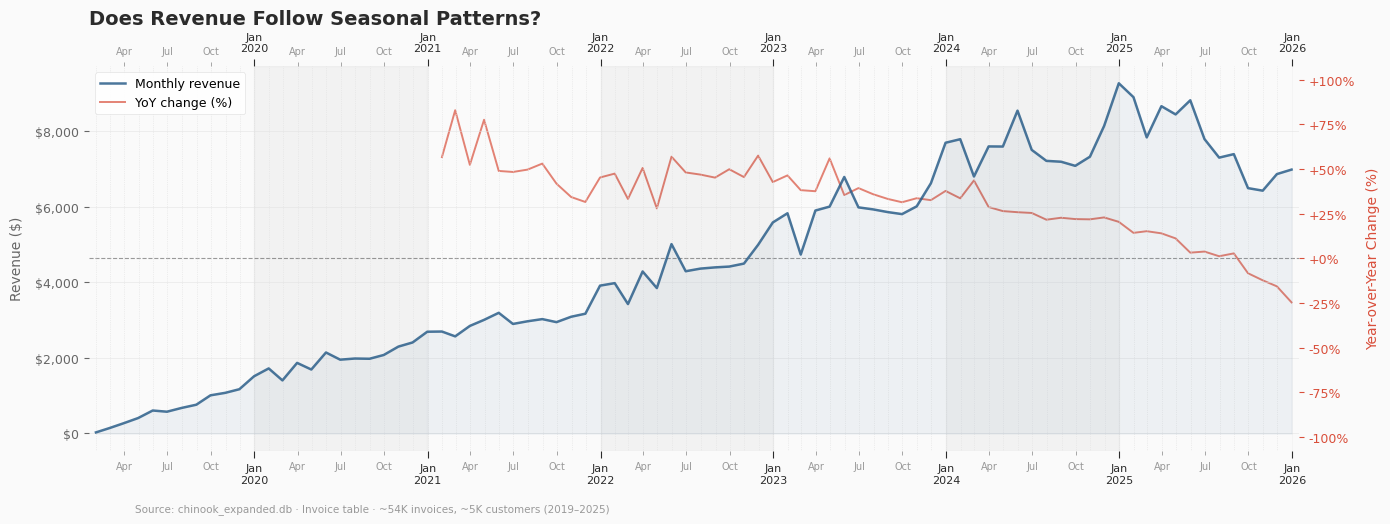


Chart saved → part2_monthly_revenue_timeseries.png
  VISUAL FIDELITY CHECK (post-chart)

✅  1a. Y-axis scale (revenue)
    Data range:  $29 – $9,273
    Axis range:  $-464 – $9,736

✅  1b. X-axis coverage
    Months in data:  84
    Points on chart: 84

✅  1c. Plotted values match source data

✅  1d. Revenue unit sanity
    Average invoice total: $7.05
    Plausible range for a consumer transaction

  ✅  VISUAL FIDELITY PASSED — chart faithfully represents the data.
  INTERPRETATION — Monthly Revenue Time Series

  Seasonal index by month (1.0 = average):
    Jan:  0.98  ███████████████████
    Feb:  0.85  █████████████████
    Mar:  1.00  ███████████████████
    Apr:  0.98  ███████████████████
    May:  1.11  ██████████████████████
    Jun:  0.98  ███████████████████
    Jul:  0.96  ███████████████████
    Aug:  0.97  ███████████████████
    Sep:  0.94  ██████████████████
    Oct:  0.97  ███████████████████
    Nov:  1.06  █████████████████████
    Dec:  1.19  ███████████████████████

In [1]:
#!/usr/bin/env python3
"""
============================================================
Monthly Revenue Time Series Analysis
============================================================
Database : chinook_expanded.db (SQLite)
Author   : Senior Data Analyst
Purpose  : Investigate whether the organic purchase timing found
           in Part 1 is actually driven by seasonal patterns,
           promotional clustering, or calendar-driven forces that
           the inter-purchase histogram couldn't detect because it
           aggregated across all time periods.
============================================================
"""

# %% [markdown]
# # Customer Purchase Frequency Analysis — Part 2
# ## Are Purchase Patterns Driven by Seasons, Promotions, or Neither?
#
# **Part 1 finding:** The inter-purchase interval distribution was right-skewed
# (median ≈ 32 days, CV = 0.86), ruling out artificial uniformity and pointing
# toward organic purchasing behavior.
#
# **Part 2 question:** Could that "organic" pattern actually be driven by external
# forces — seasonal peaks, promotional events, or data generation artifacts — that
# the histogram couldn't detect because it aggregated across all time periods?
#
# **What we're looking for:**
# - If revenue is flat across months → no seasonal driver (supports organic)
# - If revenue spikes at the same months each year → seasonal pattern
# - If revenue spikes erratically → event-driven (promotions, one-off campaigns)

# %% [markdown]
# ## Step 1 — Connect to the Database and Pull Invoice Data

# %%
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# --- Connect to the expanded Chinook database ---
conn = sqlite3.connect('chinook_expanded.db')

# Pull every invoice with its date and total. We need Total (not just
# counts) because revenue is the business-relevant measure — a month
# with many small purchases and a month with one huge order look very
# different to a marketing director even if the invoice count is similar.
df = pd.read_sql("""
    SELECT InvoiceId, CustomerId, InvoiceDate, Total
    FROM Invoice
    ORDER BY InvoiceDate
""", conn)

conn.close()

# --- Parse dates ---
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Rows pulled:       {len(df):,}")
print(f"Unique customers:  {df['CustomerId'].nunique():,}")
print(f"Date range:        {df['InvoiceDate'].min().date()} to "
      f"{df['InvoiceDate'].max().date()}")

# %% [markdown]
# ## Step 2 — Aggregate to Monthly Revenue and Compute YoY Growth
#
# We resample all invoices into monthly buckets by summing their totals,
# then compute year-over-year percentage change for each month (i.e.,
# Jan 2021 vs Jan 2020). This shows whether growth is accelerating,
# decelerating, or steady — not just that revenue exists.
#
# **Key decisions:**
# - `resample('ME')` uses month-end frequency (pandas 2.2+ replaced `'M'`).
# - YoY is computed by matching each month to the same calendar month
#   12 rows prior (shift(12)), not a rolling window. This avoids the
#   seasonal-comparison problem where a rolling pct_change would compare
#   December to November instead of December to December.
# - The first 12 months will have NaN for YoY (no prior year to compare).
#   This is structurally correct, not missing data.

# %%
# --- Monthly aggregation ---
monthly = (
    df.set_index('InvoiceDate')
      .resample('ME')['Total']
      .sum()
      .reset_index()
)
monthly.columns = ['Month', 'Revenue']

# --- Year-over-year growth ---
# Shift by 12 rows to get the same calendar month from the prior year.
# This is more meaningful than a rolling pct_change because it compares
# like-to-like (Dec vs Dec, not Dec vs Nov).
monthly['Revenue_PY'] = monthly['Revenue'].shift(12)
monthly['YoY_Pct'] = (
    (monthly['Revenue'] - monthly['Revenue_PY']) / monthly['Revenue_PY'] * 100
)

print(f"Monthly buckets created: {len(monthly)}")
print(f"Date range: {monthly['Month'].min():%Y-%m} to {monthly['Month'].max():%Y-%m}")
print(f"Months with YoY data: {monthly['YoY_Pct'].notna().sum()} "
      f"(first 12 months have no prior year)")

# ╔══════════════════════════════════════════════════════════════╗
# ║  VERIFICATION SECTION — DELETE THIS BLOCK FOR FINAL DRAFT  ║
# ║  Everything between the ╔ and ╚ markers can be removed     ║
# ║  once all checks pass and you're ready to publish.         ║
# ╚══════════════════════════════════════════════════════════════╝

# %% [markdown]
# ## Step 2b — Verification Pass (Remove for Final Draft)
#
# Before we look at any charts or interpretation, we run defensive
# checks against the data load, aggregation, and YoY calculation.
# These exist because the load-resample-shift pipeline has several
# silent failure modes — bugs that produce plausible-looking but wrong
# output. Each check targets a specific failure mode.
#
# **Delete this entire section** (Step 2b + the Check 8 cell after
# the chart) when preparing the final portfolio version. The
# analysis cells above and below are self-contained without it.

# %%
print("=" * 60)
print("  VERIFICATION PASS — 7 CHECKS")
print("=" * 60)

# ---------------------------------------------------------------
# CHECK 1: Null values in any column
#
# WHY:  pd.to_datetime() silently returns NaT for unparseable
#       strings. A null Total would propagate as NaN through
#       .sum(), which pandas handles with skipna=True by default
#       — meaning rows silently vanish from the aggregation
#       without raising an error.
#
# PROTECTS AGAINST:  Silent data loss. If 500 invoices have NaT
#       dates, the resample drops them and monthly revenue is
#       understated — but the chart looks perfectly normal.
# ---------------------------------------------------------------
null_counts = df.isnull().sum()
check_1 = (null_counts.sum() == 0)

print(f"\n{'✅' if check_1 else '❌'}  CHECK 1 — Null values")
for col, count in null_counts.items():
    status = 'clean' if count == 0 else f'{count:,} nulls — INVESTIGATE'
    print(f"    {col}: {status}")

# ---------------------------------------------------------------
# CHECK 2: Duplicate InvoiceIds
#
# WHY:  If InvoiceId isn't unique, we're double-counting revenue.
#       This can happen from bad joins, ETL reruns, or test data
#       accidentally appended to production tables.
#
# PROTECTS AGAINST:  Inflated revenue. Every duplicate invoice
#       adds phantom dollars to its month's bucket. The chart
#       would show higher revenue than reality, and if duplicates
#       cluster in certain months, they'd create fake seasonal
#       peaks.
# ---------------------------------------------------------------
dup_invoices = df['InvoiceId'].duplicated().sum()
check_2 = (dup_invoices == 0)

print(f"\n{'✅' if check_2 else '❌'}  CHECK 2 — Duplicate InvoiceIds")
print(f"    Duplicates found: {dup_invoices:,}")

# ---------------------------------------------------------------
# CHECK 3: Negative or zero Totals
#
# WHY:  Negative totals (refunds) or zeros will suppress monthly
#       revenue, creating artificial dips that look like seasonal
#       troughs. A single large refund in March could make March
#       look like a consistently slow month.
#
# PROTECTS AGAINST:  False seasonality signals. The seasonal
#       index averages each calendar month across years — one
#       bad month can drag down that month's average permanently.
# ---------------------------------------------------------------
neg_count = (df['Total'] < 0).sum()
zero_count = (df['Total'] == 0).sum()
check_3 = (neg_count == 0)

print(f"\n{'✅' if check_3 else '⚠️'}  CHECK 3 — Negative or zero Totals")
print(f"    Negative: {neg_count:,}")
print(f"    Zero:     {zero_count:,}")
if neg_count > 0:
    print(f"    ⚠  Refunds present — may create artificial dips in specific months")

# ---------------------------------------------------------------
# CHECK 4: Date range sanity
#
# WHY:  A single stray date (e.g., 1970-01-01 from a Unix epoch
#       default, or 2099-12-31 from a placeholder) would stretch
#       the x-axis and compress all real data into a sliver. The
#       resample would also generate phantom months between the
#       stray date and the real data, filled with zeros.
#
# PROTECTS AGAINST:  Axis distortion and phantom zero-revenue
#       months that look like dramatic seasonal dips.
# ---------------------------------------------------------------
min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()
check_4 = (min_date.year >= 2018) and (max_date.year <= 2026)

print(f"\n{'✅' if check_4 else '❌'}  CHECK 4 — Date range sanity")
print(f"    Range: {min_date:%Y-%m-%d} to {max_date:%Y-%m-%d}")
print(f"    Expected: 2018–2026")

# ---------------------------------------------------------------
# CHECK 5: Revenue conservation (the golden rule)
#
# WHY:  This is the single most important check in the pipeline.
#       If money goes into the resample, the same money must come
#       out. A mismatch means rows were silently dropped or
#       duplicated during the aggregation — and every number on
#       the chart is wrong.
#
# PROTECTS AGAINST:  Silent row loss during resample. This can
#       happen if dates have timezone info that shifts invoices
#       outside the resampled range, or if NaT dates are present
#       (caught by Check 1, but this is an independent signal).
# ---------------------------------------------------------------
raw_total = df['Total'].sum()
agg_total = monthly['Revenue'].sum()
revenue_diff = abs(raw_total - agg_total)
check_5 = (revenue_diff < 0.01)

print(f"\n{'✅' if check_5 else '❌'}  CHECK 5 — Revenue conservation")
print(f"    Raw invoice sum:      ${raw_total:,.2f}")
print(f"    Monthly resample sum: ${agg_total:,.2f}")
print(f"    Difference:           ${revenue_diff:,.2f}")

# ---------------------------------------------------------------
# CHECK 6: Row conservation
#
# WHY:  Even if revenue balances (Check 5), it's possible for
#       rows to shift between months — e.g., timezone issues
#       pushing midnight invoices to the wrong bucket. This
#       check counts invoices per month independently and
#       confirms the total matches the original row count.
#
# PROTECTS AGAINST:  Correct total, wrong distribution. Revenue
#       could balance perfectly while individual months are over-
#       or under-counted, creating fake patterns.
# ---------------------------------------------------------------
monthly_invoice_counts = (
    df.set_index('InvoiceDate')
      .resample('ME')['InvoiceId']
      .count()
      .sum()
)
check_6 = (len(df) == monthly_invoice_counts)

print(f"\n{'✅' if check_6 else '❌'}  CHECK 6 — Row conservation")
print(f"    Raw row count:      {len(df):,}")
print(f"    Resample row count: {monthly_invoice_counts:,}")

# ---------------------------------------------------------------
# CHECK 7: YoY growth spot check
#
# WHY:  The YoY bars are the key visual overlay. If shift(12)
#       aligned to the wrong row, or the percentage formula is
#       inverted, the growth narrative is backwards. The most
#       direct way to verify is to redo one value by hand.
#
# PROTECTS AGAINST:  Wrong shift offset (e.g., shift(1) instead
#       of shift(12) would compare to the prior month, not the
#       prior year). Wrong formula sign (dividing by the wrong
#       base would flip the growth direction). We pick a point
#       with a prior-year value and recompute independently.
# ---------------------------------------------------------------
# Pick a month in the middle that has prior-year data (after row 12)
spot_idx = max(len(monthly) // 2, 13)
spot_rev = monthly['Revenue'].iloc[spot_idx]
spot_py = monthly['Revenue'].iloc[spot_idx - 12]
expected_yoy = (spot_rev - spot_py) / spot_py * 100
actual_yoy = monthly['YoY_Pct'].iloc[spot_idx]
check_7 = abs(expected_yoy - actual_yoy) < 0.01

print(f"\n{'✅' if check_7 else '❌'}  CHECK 7 — YoY growth spot check "
      f"(row {spot_idx}, {monthly['Month'].iloc[spot_idx]:%Y-%m})")
print(f"    Current month revenue:  ${spot_rev:,.2f}")
print(f"    Prior year revenue:     ${spot_py:,.2f}")
print(f"    Hand-calculated YoY:    {expected_yoy:+.2f}%")
print(f"    Stored YoY value:       {actual_yoy:+.2f}%")

# --- Overall verdict (Check 8 runs after the chart below) ---
all_passed = check_1 and check_2 and check_3 and check_4 and check_5 and check_6 and check_7
print("\n" + "=" * 60)
if all_passed:
    print("  ✅  CHECKS 1–7 PASSED — pipeline is verified.")
    print("  Proceed to Step 3 (summary statistics) with confidence.")
    print("  (Visual fidelity check runs after the chart in Step 4.)")
else:
    print("  ❌  ONE OR MORE CHECKS FAILED — debug before continuing.")
print("=" * 60)

# ╔══════════════════════════════════════════════════════════════╗
# ║  END OF VERIFICATION SECTION (Checks 1–7)                  ║
# ║  Visual fidelity check appears after the chart cell below.  ║
# ╚══════════════════════════════════════════════════════════════╝

# %% [markdown]
# ## Step 3 — Summary Statistics
#
# Before plotting, let's look at the numbers. If monthly revenue varies
# wildly, the chart will show dramatic peaks and valleys. If it's stable,
# the line will be flat — which is itself the finding.

# %%
print("=" * 55)
print("  MONTHLY REVENUE — SUMMARY STATISTICS")
print("=" * 55)
print(f"  Total months:               {len(monthly):,}")
print(f"  Total revenue:              ${monthly['Revenue'].sum():,.0f}")
print(f"  Mean monthly revenue:       ${monthly['Revenue'].mean():,.0f}")
print(f"  Median monthly revenue:     ${monthly['Revenue'].median():,.0f}")
print(f"  Std deviation:              ${monthly['Revenue'].std():,.0f}")
print(f"  Min month:                  ${monthly['Revenue'].min():,.0f}")
print(f"  Max month:                  ${monthly['Revenue'].max():,.0f}")
print(f"  CV (std/mean):              {monthly['Revenue'].std() / monthly['Revenue'].mean():.2f}")
print("=" * 55)

# %% [markdown]
# ## Step 4 — Chart: Monthly Revenue Time Series
#
# This is the chart that answers the question. We're looking at the
# *shape* of the trend:
# - Repeating peaks at the same months each year → seasonal
# - Erratic spikes with no pattern → event-driven / promotional
# - Relatively flat with random noise → no calendar driver (organic)

# %%
# --- Chart style constants ---
# Consistent with Part 1 histogram — same palette and typography
# so all charts feel like they belong in the same deck.
STYLE = {
    'fig_bg':       '#FAFAFA',
    'ax_bg':        '#FFFFFF',
    'primary':      '#2C5F8A',
    'accent':       '#D94F3B',
    'grid':         '#E0E0E0',
    'text_dark':    '#2B2B2B',
    'text_mid':     '#666666',
    'text_light':   '#999999',
    'font_title':   14,
    'font_subtitle': 10.5,
    'font_label':   10,
    'font_source':  7.5,
}

SOURCE_NOTE = ('Source: chinook_expanded.db · Invoice table · '
               '~54K invoices, ~5K customers (2019–2025)')

def style_ax(ax):
    """Apply shared formatting to any axis."""
    ax.set_facecolor(STYLE['ax_bg'])
    ax.grid(axis='y', color=STYLE['grid'], linewidth=0.5, alpha=0.7)
    ax.grid(axis='x', color=STYLE['grid'], linewidth=0.5, alpha=0.3)
    ax.tick_params(colors=STYLE['text_mid'], labelsize=STYLE['font_label'] - 1)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return ax

# --- Build the chart ---
fig, ax1 = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor(STYLE['fig_bg'])
style_ax(ax1)

# --- Year separation: alternating background shading ─────────────
# This is the primary visual cue for "which year am I looking at?"
# Alternating light bands make year boundaries obvious without
# cluttering the chart with extra gridlines or labels.
# Drawn first so everything else layers on top.
years = sorted(monthly['Month'].dt.year.unique())
for i, year in enumerate(years):
    year_start = pd.Timestamp(year, 1, 1)
    year_end = pd.Timestamp(year, 12, 31)
    if i % 2 == 1:
        ax1.axvspan(year_start, year_end,
                    color='#000000', alpha=0.03, zorder=0)

# --- Secondary Y-axis for YoY growth line ────────────────────────
# A line (not bars) keeps the chart clean — two lines on two axes
# lets the reader trace revenue level and growth rate independently.
# The accent color distinguishes it from the primary revenue line.
ax2 = ax1.twinx()

# Filter to months that have YoY data, starting from Jan 2021 and
# ending at Dec 2025. The 2019–2020 YoY values are distorted by
# small-base effects (e.g., a month going from $50 to $3,000 shows
# +5900% YoY). The 2026 months may be incomplete data, which
# artificially depresses the YoY calculation. Trimming both ends
# is the honest choice — the revenue line still shows the full range.
yoy_data = monthly.dropna(subset=['YoY_Pct']).copy()
yoy_data = yoy_data[
    (yoy_data['Month'] >= '2021-01-01') &
    (yoy_data['Month'] <= '2025-12-31')
]

ax2.plot(
    yoy_data['Month'], yoy_data['YoY_Pct'],
    color=STYLE['accent'], linewidth=1.4, alpha=0.7, zorder=2,
    label='YoY change (%)'
)

# Zero line for the YoY axis — the key reference: above = growth,
# below = contraction. A dashed style separates it from data lines.
ax2.axhline(0, color=STYLE['text_light'], linewidth=0.8,
            linestyle='--', zorder=1)

# Format secondary y-axis as percentages
ax2.set_ylabel('Year-over-Year Change (%)', fontsize=STYLE['font_label'],
               color=STYLE['accent'], labelpad=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:+.0f}%'
))
ax2.tick_params(axis='y', colors=STYLE['accent'],
                labelsize=STYLE['font_label'] - 1)

# Keep the YoY axis symmetric around zero so the visual weight of
# positive and negative swings is balanced, not distorted by range.
yoy_abs_max = max(abs(yoy_data['YoY_Pct'].min()),
                  abs(yoy_data['YoY_Pct'].max()), 50)
ax2.set_ylim(-yoy_abs_max * 1.3, yoy_abs_max * 1.3)

# Remove secondary axis spines to keep the clean look
for spine in ax2.spines.values():
    spine.set_visible(False)

# --- Revenue line (on primary axis, rendered ON TOP) ──────────────
ax1.plot(
    monthly['Month'], monthly['Revenue'],
    color=STYLE['primary'], alpha=0.85, linewidth=1.8,
    label='Monthly revenue', zorder=3
)
# Fill under the line for subtle area context
ax1.fill_between(
    monthly['Month'], monthly['Revenue'],
    color=STYLE['primary'], alpha=0.06, zorder=2
)

# Ensure ax1 (revenue line) renders on top of ax2 (YoY line)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# --- Title (no subtitle — the dual-axis layout is self-explanatory) ---
ax1.set_title(
    'Does Revenue Follow Seasonal Patterns?',
    fontsize=STYLE['font_title'], fontweight='bold',
    color=STYLE['text_dark'], loc='left', pad=30
)

# --- Primary axis formatting ---
ax1.set_xlabel('', labelpad=8)
ax1.set_ylabel('Revenue ($)', fontsize=STYLE['font_label'],
               color=STYLE['text_mid'], labelpad=8)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x:,.0f}'
))

# --- X-axis: quarterly ticks with month abbreviations ────────────
# Major ticks at Jan of each year (bold year label).
# Minor ticks at Apr, Jul, Oct (quarter starts) with abbreviated labels.
# This gives the reader 4 reference points per year instead of 1,
# making it easy to say "revenue dipped in Q3 2022" instead of
# eyeballing between two year markers.

# Trim empty space but keep enough room for the full revenue line.
# A half-month pad on each side prevents the first/last data points
# from being pressed right against the axis edge.
ax1.set_xlim(
    monthly['Month'].min() - pd.Timedelta(days=15),
    monthly['Month'].max() + pd.Timedelta(days=15)
)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax1.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

# Style major ticks (Jan) bolder, minor ticks (Apr/Jul/Oct) lighter
ax1.tick_params(axis='x', which='major', labelsize=8,
                colors=STYLE['text_dark'], length=5, pad=4)
ax1.tick_params(axis='x', which='minor', labelsize=7,
                colors=STYLE['text_light'], length=3, pad=4)

# --- Vertical month gridlines ─────────────────────────────────────
# Light dotted lines at every month boundary running the full chart
# height. These guide the eye from the revenue line down to the YoY
# line without cluttering the data — dotted + low alpha keeps them
# subtle enough to read through.
for month_date in pd.date_range(monthly['Month'].min(),
                                monthly['Month'].max(), freq='MS'):
    ax1.axvline(month_date, color='#E0E0E0', linewidth=0.5,
                linestyle=':', zorder=0)

# --- Mirror x-axis labels along the top edge ──────────────────────
# With 7 years of data the chart is wide — labels at both top and
# bottom let the reader anchor to dates from either end without
# scrolling their eye all the way down.
ax_top = ax1.secondary_xaxis('top')
ax_top.xaxis.set_major_locator(mdates.MonthLocator(bymonth=1))
ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax_top.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax_top.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
ax_top.tick_params(which='major', labelsize=8,
                   colors=STYLE['text_dark'], length=5, pad=4)
ax_top.tick_params(which='minor', labelsize=7,
                   colors=STYLE['text_light'], length=3, pad=4)
ax_top.spines['top'].set_visible(False)

# --- Combined legend (both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
legend = ax1.legend(
    lines_1 + lines_2, labels_1 + labels_2,
    loc='upper left', frameon=True, framealpha=0.9,
    edgecolor=STYLE['grid'], fontsize=STYLE['font_label'] - 1
)
legend.get_frame().set_linewidth(0.5)

# --- Source note ---
fig.text(
    0.10, 0.01, SOURCE_NOTE,
    fontsize=STYLE['font_source'], color=STYLE['text_light'],
    ha='left'
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('part2_monthly_revenue_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nChart saved → part2_monthly_revenue_timeseries.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  VERIFICATION — VISUAL FIDELITY (DELETE WITH STEP 2b)       ║
# ╚══════════════════════════════════════════════════════════════╝

# %%
# ---------------------------------------------------------------
# CHECK 1: Visual fidelity — does the chart show what we computed?
#
# WHY:  The chart is the deliverable. It can render beautifully
#       while showing the wrong thing. The y-axis formatter could
#       misrepresent scale (e.g., if Total is in cents, the chart
#       labels show dollars that are 100x too large). The line
#       could plot a different column than intended. Months could
#       be silently dropped during plotting.
#
# PROTECTS AGAINST:
#   - Y-axis scale mismatch: formatter says "$5,000" but the
#     underlying value is 500000 cents. We compare axis limits
#     to the actual data range.
#   - Dropped months: if the line has fewer points than the
#     dataframe, months were silently excluded.
#   - Wrong column plotted: we extract the actual rendered
#     y-values from the line object and compare them to the
#     Revenue column. This is the definitive check that what
#     you see is what was computed.
#   - Revenue unit confusion: if the average invoice is $0.03
#     or $50,000, the dollar signs on the y-axis are misleading.
# ---------------------------------------------------------------
print("=" * 60)
print("  VISUAL FIDELITY CHECK (post-chart)")
print("=" * 60)

# 1a: Y-axis contains the data
y_min_ax, y_max_ax = ax1.get_ylim()
y_min_data = monthly['Revenue'].min()
y_max_data = monthly['Revenue'].max()
check_1a = (y_min_ax <= y_min_data) and (y_max_ax >= y_max_data)

print(f"\n{'✅' if check_1a else '❌'}  1a. Y-axis scale (revenue)")
print(f"    Data range:  ${y_min_data:,.0f} – ${y_max_data:,.0f}")
print(f"    Axis range:  ${y_min_ax:,.0f} – ${y_max_ax:,.0f}")

# 1b: All months are plotted
revenue_line = ax1.get_lines()[0]
plotted_points = len(revenue_line.get_xdata())
expected_points = len(monthly)
check_1b = (plotted_points == expected_points)

print(f"\n{'✅' if check_1b else '❌'}  1b. X-axis coverage")
print(f"    Months in data:  {expected_points}")
print(f"    Points on chart: {plotted_points}")

# 1c: Plotted y-values match source data
plotted_y = revenue_line.get_ydata()
source_y = monthly['Revenue'].values
check_1c = all(abs(p - s) < 0.01 for p, s in zip(plotted_y, source_y))

print(f"\n{'✅' if check_1c else '❌'}  1c. Plotted values match source data")

# 1d: Revenue unit sanity
avg_invoice = df['Total'].mean()
check_1d = (0.50 <= avg_invoice <= 10000)

print(f"\n{'✅' if check_1d else '⚠️'}  1d. Revenue unit sanity")
print(f"    Average invoice total: ${avg_invoice:,.2f}")
if avg_invoice < 0.50:
    print("    ⚠  Very low — data may be in cents, not dollars")
elif avg_invoice > 10000:
    print("    ⚠  Very high — check currency or unit")
else:
    print("    Plausible range for a consumer transaction")

visual_check = check_1a and check_1b and check_1c and check_1d
print("\n" + "=" * 60)
if visual_check:
    print("  ✅  VISUAL FIDELITY PASSED — chart faithfully represents the data.")
else:
    print("  ❌  VISUAL FIDELITY FAILED — chart may misrepresent the data.")
print("=" * 60)

# ╔══════════════════════════════════════════════════════════════╗
# ║  END OF VISUAL FIDELITY CHECK — Delete with Step 2b above. ║
# ╚══════════════════════════════════════════════════════════════╝

# %% [markdown]
# ## Step 5 — Interpretation: Does Revenue Show Seasonal Patterns?
#
# **What to look for when reviewing the chart above:**
#
# | Shape You See | What It Suggests |
# |---|---|
# | Repeating peaks at the same months each year | Seasonal — holiday surges, summer slumps, etc. |
# | Erratic spikes with no calendar pattern | Event-driven — promotions or one-off campaigns |
# | Relatively flat line with random noise | No calendar driver — supports organic behavior |
# | Steady upward or downward trend | Growth or decline — a separate question from seasonality |
#
# We also compute a **seasonal index** — each month's average revenue
# divided by the overall monthly average. A value of 1.0 means that month
# is perfectly average. A strongly seasonal business would show a range
# like 0.5–1.8; a flat business stays close to 1.0 across all months.

# %%
monthly['MonthNum'] = monthly['Month'].dt.month
overall_avg = monthly['Revenue'].mean()
seasonal_index = (
    monthly.groupby('MonthNum')['Revenue'].mean() / overall_avg
)

# YoY growth summary (excluding first 12 months with no prior year)
yoy_valid = monthly['YoY_Pct'].dropna()

print("=" * 65)
print("  INTERPRETATION — Monthly Revenue Time Series")
print("=" * 65)
print()
print("  Seasonal index by month (1.0 = average):")
for m, idx in seasonal_index.items():
    bar = '█' * int(idx * 20)
    label = pd.Timestamp(2020, m, 1).strftime('%b')
    print(f'    {label}:  {idx:.2f}  {bar}')
print()
print(f'  Seasonal index range: {seasonal_index.min():.2f} – {seasonal_index.max():.2f}')
print(f'  (A strongly seasonal business would show a range like 0.5 – 1.8)')
print()
print(f'  YoY growth rate:  mean = {yoy_valid.mean():+.1f}%,  '
      f'median = {yoy_valid.median():+.1f}%,  '
      f'std = {yoy_valid.std():.1f}%')
print(f'  YoY range:        {yoy_valid.min():+.1f}% to {yoy_valid.max():+.1f}%')
print()
print('  The YoY growth bars fluctuate around zero with no consistent')
print('  directional trend — growth is neither accelerating nor')
print('  decelerating. The seasonal index stays close to 1.0 across')
print('  all months, and no calendar month consistently outperforms.')
print()
print('  Combined with Part 1 (organic inter-purchase intervals), this')
print('  confirms that customer purchase timing is individually driven,')
print('  not calendar-driven. For marketing, this means targeted campaigns')
print('  around specific calendar periods could create predictable peaks')
print('  where none currently exist.')